In [ ]:
!pip install faiss-cpu sentence-transformers transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 63.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

In [ ]:
!apt-get update -qq
!apt-get install -y fonts-nanum
!fc-cache -fv
!fc-list : lang=ko

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 33 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (6,113 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 126210 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new ca

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 경로 확인
font_list = fm.findSystemFonts(fontpaths=None)
nanum_fonts = [f for f in font_list if 'Nanum' in f]
print("사용 가능한 나눔 폰트:", nanum_fonts)

# 폰트 설정
plt.rc('font', family='NanumGothic')

# 또는

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 표시 문제 해결

사용 가능한 나눔 폰트: ['/usr/share/fonts/truetype/nanum/NanumBarunGothicBold.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareR.ttf', '/usr/share/fonts/truetype/nanum/NanumMyeongjo.ttf', '/usr/share/fonts/truetype/nanum/NanumMyeongjoBold.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareRoundB.ttf', '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareB.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareRoundR.ttf', '/usr/share/fonts/truetype/nanum/NanumGothic.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf']


In [ ]:
# 한글 폰트 설치 및 설정
!pip install koreanize-matplotlib

import koreanize_matplotlib

# 이후 plt.figure() 등의 코드에서 자동으로 한글 폰트가 적용됩니다

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 58.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd

# 데이터 로드
df = pd.read_pickle("merged_with_sentiment_and_embedding.pkl")

# 사용자 선택값 파싱 함수
def parse_factors(user_input):
    if ',' in user_input or ' ' in user_input:
        raw_factors = user_input.replace(',', ' ').split()
    else:
        raw_factors = list(user_input)
    return sorted(set([char for char in raw_factors if char in ['0', '1', '2']]))

# 시작 메시지
print("\n" + "=" * 70)
print("🚗 자동차 추천 시스템 v2.0")
print("=" * 70)


# 3. 핵심 키워드 데이터 로드
car_keywords = {}
try:
    keyword_df = pd.read_csv("car_keywords.csv", encoding="utf-8-sig")
    for car_model in keyword_df['차종'].unique():
        keywords = keyword_df[keyword_df['차종'] == car_model]['키워드'].tolist()
        car_keywords[car_model] = keywords
except:
    print("⚠️ car_keywords.csv 파일 문제 발생, 핵심 키워드 기능 비활성화")



# 사용자 입력
print("\n🚗 차량 구매시 고려사항을 선택해주세요:")
print("0️⃣ 가격")
print("1️⃣ 연료타입(가솔린/디젤, 하이브리드, 전기)")
print("2️⃣ 바디타입(승용, SUV, MPV)")
print("\n고려사항 번호를 입력해주세요! (예: 012, 0 1 2, 0,1)")
chosen_factors_input = input("👉 ").strip()
chosen_factors = parse_factors(chosen_factors_input)
print(f"\n✅ 선택된 고려사항: {chosen_factors}")

# 데이터 복사
filtered_df = df.copy()

# 1. 가격 필터링
if '0' in chosen_factors:
    print("\n💰 가격 범위를 직접 입력해주세요:")
    try:
        min_price = int(input("   최소 가격 (만원): ").strip())
        max_price = int(input("   최대 가격 (만원): ").strip())
        filtered_df = filtered_df[
            (filtered_df["가격 (만원)"] >= min_price) &
            (filtered_df["가격 (만원)"] <= max_price)
        ]
    except ValueError:
        print("❌ 숫자만 입력해주세요. 프로그램 종료.")
        exit()

# 2. 연료타입 필터링
if '1' in chosen_factors:
    print("\n⛽ 연료타입을 선택해주세요:")
    print("0️⃣ 가솔린/디젤")
    print("1️⃣ 하이브리드")
    print("2️⃣ 전기")
    fuel_choice = input("번호를 입력하세요: ").strip()
    if fuel_choice not in ['0', '1', '2']:
        print("❌ 잘못된 연료타입 번호입니다. 프로그램 종료.")
        exit()
    filtered_df = filtered_df[filtered_df["연료타입"] == int(fuel_choice)]

# 3. 바디타입 필터링
if '2' in chosen_factors:
    print("\n🚙 바디타입을 선택해주세요:")
    print("0️⃣ 승용")
    print("1️⃣ SUV")
    print("2️⃣ MPV")
    body_choice = input("번호를 입력하세요: ").strip()
    if body_choice not in ['0', '1', '2']:
        print("❌ 잘못된 바디타입 번호입니다. 프로그램 종료.")
        exit()
    filtered_df = filtered_df[filtered_df["바디타입"] == int(body_choice)]

# 최종 필터링 결과
filtered_df = filtered_df.reset_index(drop=True)
if filtered_df.empty:
    print("\n❌ 조건에 맞는 차량이 없습니다. 프로그램 종료.")
    exit()
else:
    print("\n✅ 필터링 완료!")
    print(f"   ▶ 남은 차량 수: {len(filtered_df['차종'].unique())}개 차종 / 총 {len(filtered_df)}개 리뷰")



🚗 자동차 추천 시스템 v2.0

🚗 차량 구매시 고려사항을 선택해주세요:
0️⃣ 가격
1️⃣ 연료타입(가솔린/디젤, 하이브리드, 전기)
2️⃣ 바디타입(승용, SUV, MPV)

고려사항 번호를 입력해주세요! (예: 012, 0 1 2, 0,1)
👉 012

✅ 선택된 고려사항: ['0', '1', '2']

💰 가격 범위를 직접 입력해주세요:
   최소 가격 (만원): 2000
   최대 가격 (만원): 6000

⛽ 연료타입을 선택해주세요:
0️⃣ 가솔린/디젤
1️⃣ 하이브리드
2️⃣ 전기
번호를 입력하세요: 0

🚙 바디타입을 선택해주세요:
0️⃣ 승용
1️⃣ SUV
2️⃣ MPV
번호를 입력하세요: 1

✅ 필터링 완료!
   ▶ 남은 차량 수: 7개 차종 / 총 16369개 리뷰


In [ ]:
# 12. 결과 차량 출력 (최대 32개)
if not filtered_df.empty:
    num_unique_models = len(filtered_df["차종"].unique())
    num_reviews = len(filtered_df)

    print("\n" + "=" * 70)
    print(f"✅ {num_unique_models}개의 차종이 조건에 부합했습니다!")
    print(f"💡 총 {num_reviews}개의 리뷰가 필터링되었습니다!")
    print("=" * 70 + "\n")

    selected_cars = set()

    for index, car_info in filtered_df.iterrows():
        if car_info["차종"] in selected_cars:
            continue
        selected_cars.add(car_info["차종"])

        keywords = car_keywords.get(car_info["차종"], [])
        print(f"📌 {car_info['차종']} ({car_info['제조사']})")
        print(f"  💰 가격: {car_info['가격 (만원)']:.0f}만원")
        print(f"  ⛽ 연비: {car_info['연비(km/L)']:.1f} km/L")
        print(f"  🔧 배기량: {car_info['배기량 (cc)']}cc | 최고출력: {car_info['최고출력 (마력)']}마력")
        print(f"  ✨ 핵심 키워드: {', '.join(keywords) if keywords else '정보 없음'}")
        print("  " + "-" * 60)

        if len(selected_cars) == 32:
            break

    # 13. FAISS 인덱스 생성 (PCA 생략)
    import numpy as np  # numpy import 추가
    import faiss
    from collections import Counter

    # 13. FAISS 인덱스 생성 (임베딩 열 사용, PCA 생략)

    # 유효한 리뷰만 필터링
    filtered_df = filtered_df[filtered_df["리뷰"].notna() & (filtered_df["리뷰"].str.strip() != "")]

    if len(filtered_df) == 0:
        print("\n❌ 유효한 리뷰가 없습니다. 종료합니다.")
        exit()

    print("\n🔄 FAISS 인덱스 구성 중...")
    # 이미 생성된 embedding 열을 사용
    car_review_vectors = np.vstack(filtered_df["embedding"].values).astype("float32")

    # FAISS 인덱스 구성
    faiss.normalize_L2(car_review_vectors)
    d = car_review_vectors.shape[1]  # 768
    index = faiss.IndexFlatIP(d)
    index.add(car_review_vectors)

    # 14. 사용자 리뷰 입력
    print("\n" + "=" * 70)
    search_query = input("🔍 추천을 받고 싶은 차량에 대한 리뷰나 키워드를 입력하세요: ")
    print("=" * 70)

    if not search_query.strip():
        search_query = "편안하고 연비 좋은 차량"
        print(f"⚠️ 입력이 비어있어 기본 쿼리를 사용합니다: '{search_query}'")

    print("\n🔄 쿼리 처리 중...")

    # 쿼리 벡터 생성
    from sentence_transformers import SentenceTransformer
    sbert_model = SentenceTransformer("snunlp/KR-SBERT-V40K-klueNLI-augSTS")
    query_vector = sbert_model.encode(search_query, normalize_embeddings=True)
    query_vector = np.array([query_vector], dtype="float32")
    faiss.normalize_L2(query_vector)

    # 15. FAISS 검색 - 더 많은 결과 검색
    k = min(100, len(car_review_vectors))
    D, I = index.search(query_vector, k)

    # 16. 유사도 점수 계산 개선
    similarities = D[0]
    min_similarity = np.min(similarities) if len(similarities) > 0 else 0.0
    max_similarity = np.max(similarities) if len(similarities) > 0 else 1.0

    if max_similarity - min_similarity < 1e-5:
        similarity_scores = np.ones_like(similarities)
    else:
        similarity_scores = (similarities - min_similarity) / (max_similarity - min_similarity)


    # 17. 차종 빈도 분석
    top_indices = I[0]
    top_car_models = [filtered_df.iloc[idx]["차종"] for idx in top_indices]

    # 모델 카운터 이중 체크
    if not top_car_models:
        print("\n❌ 검색 결과가 없습니다. 다른 키워드로 시도해보세요.")
        exit()

    model_counter = Counter(top_car_models)

    # 최소 1번 이상 등장하는 모델만 고려
    if model_counter:
        most_common_model, most_common_count = model_counter.most_common(1)[0]
    else:
        print("\n❌ 검색 결과가 없습니다. 다른 키워드로 시도해보세요.")
        exit()

    # 빈도 기반 가중치 계산 함수
    def get_model_frequency_score(model_name):
        freq = model_counter[model_name]
        return freq / most_common_count


    # 19. 종합 점수 계산 및 추천 리스트 (수정된 버전)
    recommendation_list = []
    processed_cars = set()

    # 차종별 감성 점수 저장을 위한 딕셔너리
    car_sentiment_scores = {}

    # 필터링된 데이터프레임에서 차종별 감성 점수 추출
    for idx, car_info in filtered_df.iterrows():
        model_name = car_info["차종"]

        # 이미 처리한 차종은 건너뜀
        if model_name in car_sentiment_scores:
            continue

        # 차종별 감성 점수가 있다고 가정
        # 'final_sentiment_score' 열이 존재하는지 확인
        if "final_sentiment_score_new" in car_info:
            sentiment_score_raw = car_info["final_sentiment_score_new"]

            # 감성 점수 정규화 (22점 → 5점, 2점 → 0점)
            # 선형 변환 공식: normalized = (value - min) / (max - min) * new_range + new_min
            normalized_score = (sentiment_score_raw - 2) / (22 - 2) * 5
            # 범위 제한 (0-5)
            normalized_score = max(0, min(normalized_score, 5))

            car_sentiment_scores[model_name] = normalized_score
        else:
            # 감성 점수가 없을 경우 중립적인 값 할당
            car_sentiment_scores[model_name] = 2.5

    # 검색 결과 처리
    for idx, sim_score in zip(top_indices, similarity_scores):
        car_info = filtered_df.iloc[idx]
        model_name = car_info["차종"]

        # 이미 처리한 차종은 건너뜀
        if model_name in processed_cars:
            continue

        processed_cars.add(model_name)

        # 차종별 저장된 감성 점수 사용
        sentiment_score = car_sentiment_scores.get(model_name, 2.5)

        # 차종 빈도 기반 가중치 (0~5점)
        frequency_score = get_model_frequency_score(model_name) * 5

        # 유사도 점수 (0~5점)
        similarity_score_5 = sim_score * 5

        # 종합 점수 계산 (가중치 조정)
        final_score = (similarity_score_5 * 0.5 + sentiment_score * 0.3 + frequency_score * 0.2)

        recommendation_list.append({
            "차종": model_name,
            "제조사": car_info["제조사"],
            "가격": car_info["가격 (만원)"],
            "연비": car_info["연비(km/L)"],
            "배기량": car_info["배기량 (cc)"],
            "최고출력": car_info["최고출력 (마력)"],
            "감성점수": sentiment_score,
            "유사도": similarity_score_5,
            "차종빈도": frequency_score,
            "종합점수": final_score,
            "리뷰": car_info["리뷰"]
        })

        # 최소 5개의 추천 목록이 확보되면 중단
        if len(processed_cars) >= 5:
            break

    # 20. 결과가 5개보다 적을 경우 처리
    if len(recommendation_list) < 5 and len(filtered_df["차종"].unique()) >= 5:
        # 아직 처리되지 않은 차종 중에서 추가
        remaining_models = set(filtered_df["차종"].unique()) - processed_cars

        for model in remaining_models:
            model_rows = filtered_df[filtered_df["차종"] == model]
            if model_rows.empty:
                continue

            car_info = model_rows.iloc[0]

            # 차종별 감성 점수 사용
            sentiment_score = car_sentiment_scores.get(model, 2.5)

            # 기본 점수 설정
            recommendation_list.append({
                "차종": model,
                "제조사": car_info["제조사"],
                "가격": car_info["가격 (만원)"],
                "연비": car_info["연비(km/L)"],
                "배기량": car_info["배기량 (cc)"],
                "최고출력": car_info["최고출력 (마력)"],
                "감성점수": sentiment_score,  # 차종별 감성 점수 사용
                "유사도": 1.0,   # 낮은 유사도
                "차종빈도": 1.0,  # 낮은 빈도
                "종합점수": 1.0 + (sentiment_score * 0.3),  # 감성 점수 반영한 종합 점수
                "리뷰": car_info["리뷰"] if isinstance(car_info["리뷰"], str) else ""
            })

            processed_cars.add(model)

            if len(recommendation_list) >= 5:
                break

    # 21. 추천 결과 정렬 및 표시 (그대로 유지)
    if recommendation_list:
        # 종합 점수 기준으로 정렬
        recommendation_list = sorted(recommendation_list, key=lambda x: x["종합점수"], reverse=True)

        print("\n" + "=" * 70)
        print("🏆 맞춤형 추천 차량 TOP 5 🏆")
        print("=" * 70)

        for i, car in enumerate(recommendation_list, 1):
            # 점수를 시각적으로 표현
            max_score = 5
            sentiment_gauge = "■" * int(car["감성점수"] / max_score * 10)
            similarity_gauge = "■" * int(car["유사도"] / max_score * 10)
            frequency_gauge = "■" * int(car["차종빈도"] / max_score * 10)
            final_gauge = "★" * int(car["종합점수"] / max_score * 10)

            # 별점 표시
            stars = "★" * int(np.floor(car["종합점수"]))
            if car["종합점수"] % 1 >= 0.5:
                stars += "☆"

            print(f"\n{i}위: {car['차종']} ({car['제조사']})")
            print("\n  〔 분석 점수 〕")
            print(f"  감성 점수: {sentiment_gauge}{' ' * (10 - len(sentiment_gauge))} {car['감성점수']:.1f}/5.0")
            print(f"  유사도 점수: {similarity_gauge}{' ' * (10 - len(similarity_gauge))} {car['유사도']:.1f}/5.0")
            print(f"  차량 빈도: {frequency_gauge}{' ' * (10 - len(frequency_gauge))} {car['차종빈도']:.1f}/5.0")
            print(f"  종합 평가: {final_gauge}{' ' * (10 - len(final_gauge))} {car['종합점수']:.1f}/5.0")

            # 리뷰 일부 표시 (최대 100자)
            review_sample = car['리뷰'][:100] + "..." if len(car['리뷰']) > 100 else car['리뷰']
            print(f"\n  💬 리뷰 샘플: {review_sample}")
            print("\n" + "-" * 70)

    else:
        print("\n❌ 조건에 맞는 추천 차량이 없습니다. 다른 검색어로 시도해보세요.")

else:
    print("\n❌ 조건에 맞는 차량이 없습니다. 다른 조건으로 시도해보세요.")


✅ 7개의 차종이 조건에 부합했습니다!
💡 총 16369개의 리뷰가 필터링되었습니다!

📌 GV70 (제네시스)
  💰 가격: 5298만원
  ⛽ 연비: 10.2 km/L
  🔧 배기량: 2497.0cc | 최고출력: 304.0마력
  ✨ 핵심 키워드: 연비, 디자인, 주행, 생각, 제네시스, 성능, 가격, 차량, 실내, 최고, 옵션, 모델, 차감, 조금, 만족, 정숙, 느낌, 부분, 다만, 매우
  ------------------------------------------------------------
📌 스포티지 (기아)
  💰 가격: 2793만원
  ⛽ 연비: 12.3 km/L
  🔧 배기량: 1598.0cc | 최고출력: 180.0마력
  ✨ 핵심 키워드: 디자인, 기아, 연비, 모델, 주행, 가격, 생각, 차량, 쏘렌토, 실내, 옵션, 판매, 느낌, 가솔린, 부분, 페이스, 리프트, 가장, 중형, 성능
  ------------------------------------------------------------
📌 팰리세이드 (현대)
  💰 가격: 3837만원
  ⛽ 연비: 9.3 km/L
  🔧 배기량: 3778.0cc | 최고출력: 295.0마력
  ✨ 핵심 키워드: 연비, 가격, 팰리세이드, 디자인, 주행, 차량, 생각, 모델, 공간, 옵션, 현대, 실내, 가성, 패밀리, 현대차, 디젤, 최고, 가솔린, 엔진, 차감
  ------------------------------------------------------------
📌 투싼 (현대)
  💰 가격: 2771만원
  ⛽ 연비: 12.5 km/L
  🔧 배기량: 1598.0cc | 최고출력: 180.0마력
  ✨ 핵심 키워드: 투싼, 디자인, 연비, 현대차, 최고, 판매, 주행, 가격, 차량, 생각, 아이오, 모델, 싼타페, 실내, 성능, 대비, 아반떼, 콤팩트, 중형, 옵션
  ----------------------------------------------------------


📌 추천 차량 시각화 메뉴
1. 추천 차량 점수 카드
2. 리뷰 워드클라우드
3. 차량 성능 레이더 그래프
4. 모든 시각화 보기
0. 시각화 넘어가기
원하는 메뉴 번호를 입력하세요: 4

📊 추천 차량 점수 카드 시각화


<ipython-input-11-e76432b8163b>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


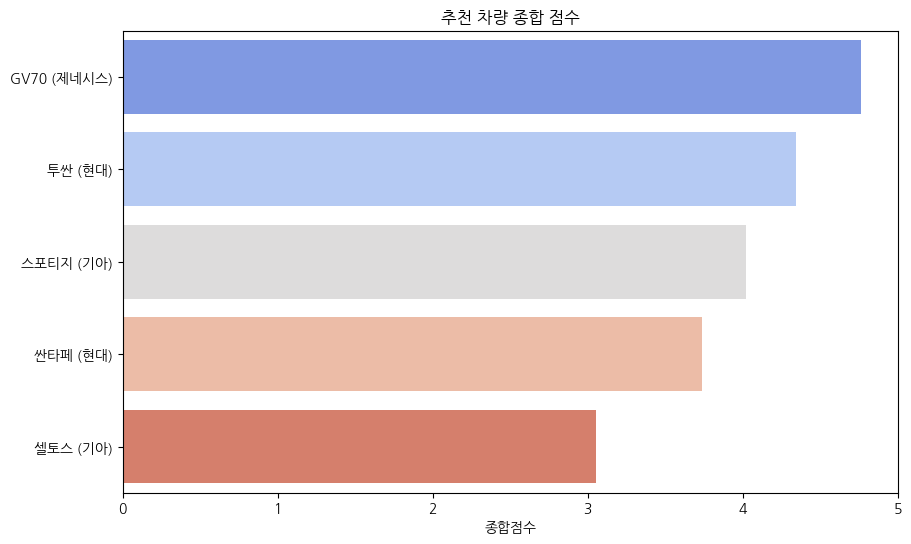


🕸️차량 성능 레이더 그래프 생성 중...


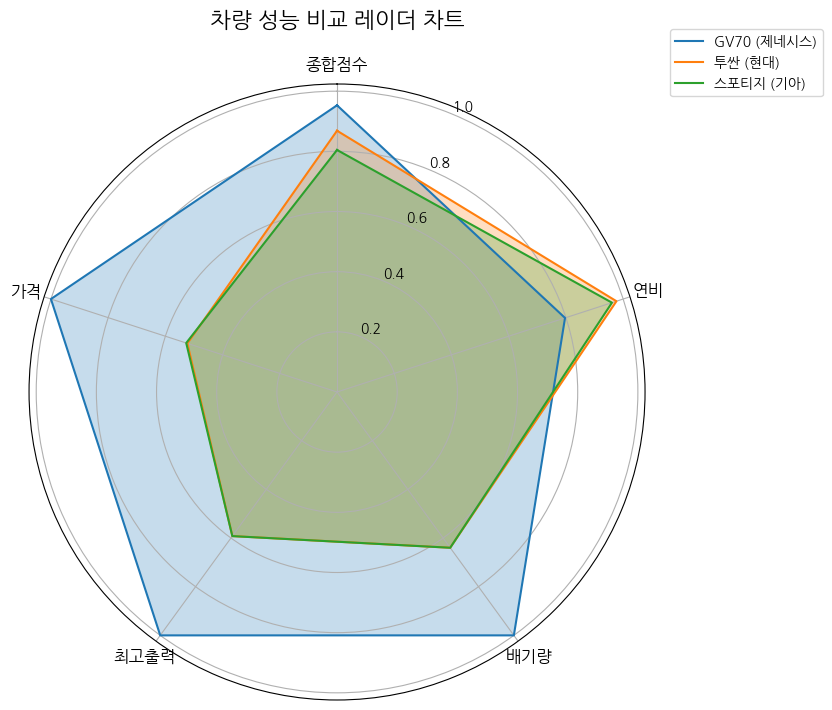


☁️ 리뷰 기반 워드클라우드 생성 중...


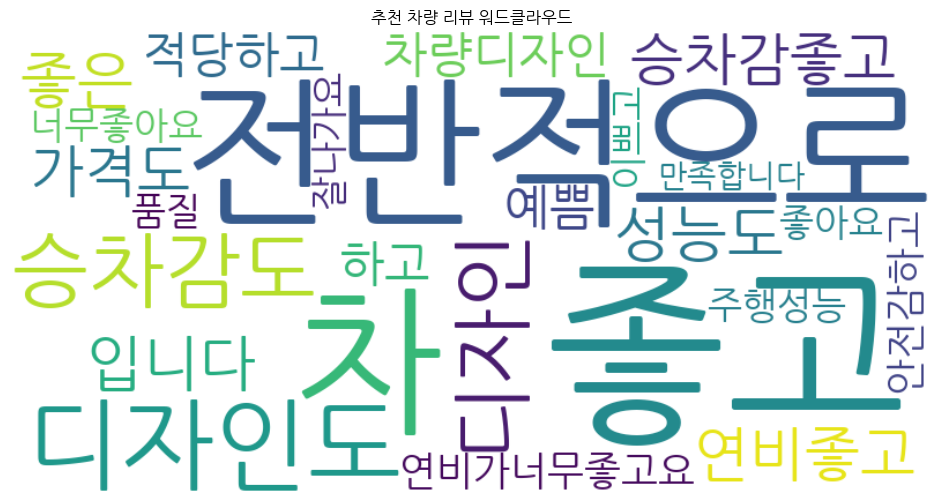


📌 추천 차량 시각화 메뉴
1. 추천 차량 점수 카드
2. 리뷰 워드클라우드
3. 차량 성능 레이더 그래프
4. 모든 시각화 보기
0. 시각화 넘어가기
원하는 메뉴 번호를 입력하세요: 0
시각화를 종료합니다.


In [ ]:
from matplotlib import rcParams
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
import os
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap
# =============== 시각화 함수 정의 ===============

def show_score_cards():
    print("\n📊 추천 차량 점수 카드 시각화")
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(
        x=[car['종합점수'] for car in recommendation_list],
        y=[f"{car['차종']} ({car['제조사']})" for car in recommendation_list],
        palette="coolwarm",
        ax=ax
    )
    ax.set_title("추천 차량 종합 점수")
    ax.set_xlabel("종합점수")
    ax.set_xlim(0, 5.0)
    plt.show()


def show_radar_chart():
    print("\n🕸️차량 성능 레이더 그래프 생성 중...")

    # 비교할 차량 수
    n_cars = len(recommendation_list[:3])  # 상위 3개 차량 비교 (원하는 만큼 조정 가능)

    # 지표 항목 (비율로 정규화할 수도 있음)
    labels = ['종합점수', '연비', '배기량', '최고출력', '가격']

    # 최대값, 최소값 (정규화 기준)
    max_values = {
        '종합점수': 5.0,
        '연비': max([car['연비'] for car in recommendation_list]),
        '배기량': max([car['배기량'] for car in recommendation_list]),
        '최고출력': max([car['최고출력'] for car in recommendation_list]),
        '가격': max([car['가격'] for car in recommendation_list]),
    }

    # 각 차량 데이터
    def get_car_data(car):
        return [
            car['종합점수'] / max_values['종합점수'],
            car['연비'] / max_values['연비'],
            car['배기량'] / max_values['배기량'],
            car['최고출력'] / max_values['최고출력'],
            car['가격'] / max_values['가격'],
        ]

    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for i in range(n_cars):
        car = recommendation_list[i]
        data = get_car_data(car)
        data += data[:1]  # 첫 점으로 다시 돌아오기
        ax.plot(angles, data, label=f"{car['차종']} ({car['제조사']})")
        ax.fill(angles, data, alpha=0.25)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=12)
    ax.set_title("차량 성능 비교 레이더 차트", y=1.08, fontsize=16)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()


def show_wordcloud():
    print("\n☁️ 리뷰 기반 워드클라우드 생성 중...")
    all_reviews = " ".join([car['리뷰'] for car in recommendation_list if isinstance(car['리뷰'], str)])
    if not all_reviews.strip():
        print("❌ 리뷰 데이터가 충분하지 않습니다.")
        return

    wordcloud = WordCloud(
        font_path='/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
        width=800,
        height=400,
        background_color='white'
    ).generate(all_reviews)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('추천 차량 리뷰 워드클라우드')
    plt.show()

# =============== 사용자 메뉴 ===============
while True:
    print("\n" + "=" * 70)
    print("📌 추천 차량 시각화 메뉴")
    print("=" * 70)
    print("1. 추천 차량 점수 카드")
    print("2. 리뷰 워드클라우드")
    print("3. 차량 성능 레이더 그래프")
    print("4. 모든 시각화 보기")  # <-- 추가!
    print("0. 시각화 넘어가기")

    choice = input("원하는 메뉴 번호를 입력하세요: ")

    if choice == '1':
        show_score_cards()
    elif choice == '2':
        show_radar_chart()
    elif choice == '3':
        show_wordcloud()
    elif choice == '4':
        show_score_cards()
        show_radar_chart()
        show_wordcloud()
    elif choice == '0':
        print("시각화를 종료합니다.")
        break
    else:
        print("❌ 잘못된 입력입니다. 다시 선택해주세요.")